# Delamanid ablation comparison (corrected lineage orientation)

Three CMM-logistic stability-selection runs (`max_parents=4`, `k_max=6`, `min_cluster_count=4`, 100 subsamples at 80%) under the **corrected** orientation where lineage is downstream of mutations (mutation->lineage allowed, lineage->mutation forbidden, lineage->dlm_mic allowed).

1. `baseline`: mutation features only (lineage-free; reused unchanged from the original run)
2. `with_lineage`: + one-hot lineage (`lineage_2`, `lineage_4`)
3. `with_lineage_and_type`: + `type_beyond_MDR`

Results in `tb_subsampling_dlm_mp4_k6_mcc4_linfix/`. This supersedes `delamanid_ablation_comparison.ipynb` (lineage-exogenous orientation), which is kept as the historical record. Captions here are factual; interpretation is left to the writeup.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[2]))
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().parents[2]
RESULTS = ROOT / 'results' / 'mixed_cmm' / 'subsampling' / 'tb_subsampling_dlm_mp4_k6_mcc4_linfix'
OLD = ROOT / 'results' / 'mixed_cmm' / 'subsampling' / 'tb_subsampling_dlm_mp4_k6_mcc4'
CONDITIONS = ['baseline', 'with_lineage', 'with_lineage_and_type']
SHORT = {'baseline': 'baseline', 'with_lineage': '+lineage', 'with_lineage_and_type': '+lineage+type'}
MIN_ELIGIBLE = 50
COVARIATES = {'lineage_2', 'lineage_4', 'type_beyond_MDR'}
edges = {c: pd.read_csv(RESULTS / c / 'edge_stability.csv') for c in CONDITIONS}
kdist = {c: pd.read_csv(RESULTS / c / 'per_node_k.csv') for c in CONDITIONS}

## dlm_mic mixture order

Mode and distribution of the chosen cluster count k for the `dlm_mic` node across the three conditions.

In [2]:
rows = []
for c in CONDITIONS:
    row = kdist[c][kdist[c]['feature'] == 'dlm_mic'].iloc[0]
    k6 = int(row['k6_count']) if 'k6_count' in row.index else 0
    rows.append({'condition': SHORT[c], 'mode_k': int(row['mode_k']), 'k=6 share': k6 / 100, 'mean_k': round(float(row['mean_k']), 2)})
pd.DataFrame(rows)

,condition,mode_k,k=6 share,mean_k
0,baseline,6,0.49,5.35
1,+lineage,6,0.51,5.37
2,+lineage+type,6,0.46,5.34


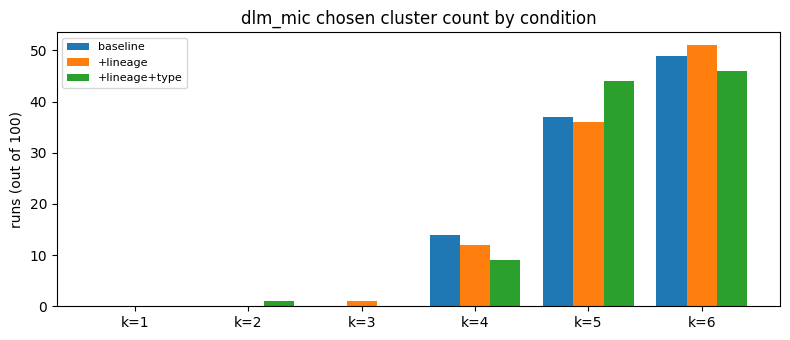

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.5))
k_cols = ['k1_count', 'k2_count', 'k3_count', 'k4_count', 'k5_count', 'k6_count']
x = np.arange(6); n = len(CONDITIONS); width = 0.8 / n
for i, c in enumerate(CONDITIONS):
    row = kdist[c][kdist[c]['feature'] == 'dlm_mic'].iloc[0]
    counts = [int(row[col]) if col in row.index else 0 for col in k_cols]
    ax.bar(x + i * width, counts, width, label=SHORT[c])
ax.set_xticks(x + (n - 1) / 2 * width); ax.set_xticklabels(['k=1', 'k=2', 'k=3', 'k=4', 'k=5', 'k=6'])
ax.set_ylabel('runs (out of 100)'); ax.set_title('dlm_mic chosen cluster count by condition')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## mutation -> dlm_mic stability

Selection frequency of each `mutation -> dlm_mic` edge under each condition (lineage/type covariates excluded from the variant axis; edges with fewer than 50 eligible subsamples treated as 0). Dashed line is the 0.5 Meinshausen-Buhlmann threshold.

In [4]:
def freq_to_mic(df, source):
    sub = df[(df['target'] == 'dlm_mic') & (df['source'] == source) & (df['n_eligible'] >= MIN_ELIGIBLE)]
    return float(sub['frequency'].iloc[0]) if len(sub) else 0.0
variants = sorted({s for c in CONDITIONS for s in edges[c]['source'].unique()} - COVARIATES)
table = pd.DataFrame({SHORT[c]: [freq_to_mic(edges[c], v) for v in variants] for c in CONDITIONS}, index=variants)
table = table.sort_values(SHORT['with_lineage'], ascending=False)
table.round(2)

,baseline,+lineage,+lineage+type
rv1979c_C*135G,0.55,0.49,0.35
rv0678_G*128C,0.30,0.45,0.23
pepq_Ala87Gly,0.27,0.37,0.38
mmpl5_Asp767Asn,0.38,0.36,0.19
mmpl5_Thr794Ile,0.14,0.18,0.27
fgd1_Phe320Phe,0.06,0.17,0.00
fgd1_G*357C,0.17,0.14,0.19
fgd1_Lys270Met,0.00,0.00,0.00
mmpl5_Ile948Val,0.00,0.00,0.00


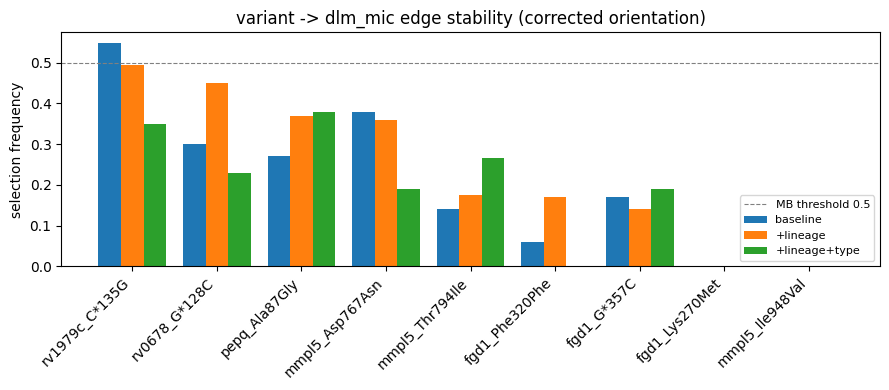

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(table)); n = len(CONDITIONS); width = 0.8 / n
for i, c in enumerate(CONDITIONS):
    ax.bar(x + i * width, table[SHORT[c]].values, width, label=SHORT[c])
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='MB threshold 0.5')
ax.set_xticks(x + (n - 1) / 2 * width); ax.set_xticklabels(table.index, rotation=45, ha='right')
ax.set_ylabel('selection frequency'); ax.set_title('variant -> dlm_mic edge stability (corrected orientation)')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## lineage edges under the corrected orientation

With lineage downstream of mutations, lineage can only parent `dlm_mic` (lineage->mutation is forbidden), while mutations may parent lineage. Outgoing (`lineage -> dlm_mic`) and the top incoming (`mutation -> lineage`) edges, from the `with_lineage` run.

In [6]:
df = edges['with_lineage']
out = df[df['source'].isin(['lineage_2', 'lineage_4']) & (df['n_eligible'] >= MIN_ELIGIBLE)]
inc = df[df['target'].isin(['lineage_2', 'lineage_4']) & (df['n_eligible'] >= MIN_ELIGIBLE)]
print('edges out of lineage (only -> dlm_mic is allowed):')
display(out[['source', 'target', 'frequency']].round(2).sort_values('frequency', ascending=False).reset_index(drop=True))
print('top edges into lineage (mutation -> lineage, the corrected direction):')
display(inc[['source', 'target', 'frequency']].round(2).sort_values('frequency', ascending=False).head(8).reset_index(drop=True))

edges out of lineage (only -> dlm_mic is allowed):


,source,target,frequency


top edges into lineage (mutation -> lineage, the corrected direction):


,source,target,frequency
0,mmpl5_Asp767Asn,lineage_2,0.96
1,mmpl5_Thr794Ile,lineage_4,0.59
2,rv0678_G*128C,lineage_2,0.55
3,fgd1_G*357C,lineage_4,0.34
4,mmpl5_Asp767Asn,lineage_4,0.26
5,fgd1_G*357C,lineage_2,0.25
6,fgd1_Phe320Phe,lineage_4,0.21
7,mmpl5_Thr794Ile,lineage_2,0.18


## type_beyond_MDR outgoing edges (with_lineage_and_type)

Type is exogenous (incoming edges forbidden); its outgoing edge frequencies.

In [7]:
df = edges['with_lineage_and_type']
type_out = df[(df['source'] == 'type_beyond_MDR') & (df['n_eligible'] >= MIN_ELIGIBLE)].sort_values('frequency', ascending=False)
type_out[['source', 'target', 'count', 'n_eligible', 'frequency']].round(3).reset_index(drop=True)

,source,target,count,n_eligible,frequency
0,type_beyond_MDR,pepq_Ala87Gly,51,64,0.797
1,type_beyond_MDR,dlm_mic,40,59,0.678
2,type_beyond_MDR,mmpl5_Thr794Ile,34,64,0.531


## old vs corrected: dlm_mic parents

Selection frequency of each feature as a parent of `dlm_mic`, lineage-exogenous (original) vs lineage-downstream (corrected), for the two lineage-bearing conditions.

In [8]:
def mic_parents(base, cond):
    d = pd.read_csv(base / cond / 'edge_stability.csv')
    d = d[d['target'] == 'dlm_mic']
    return d.set_index('source')['frequency']
for cond in ['with_lineage', 'with_lineage_and_type']:
    old = mic_parents(OLD, cond); new = mic_parents(RESULTS, cond)
    cmp = pd.DataFrame({'old (lineage exogenous)': old, 'corrected': new}).fillna(0)
    cmp = cmp.sort_values('corrected', ascending=False).round(3)
    print(cond + ': dlm_mic parents')
    display(cmp)

with_lineage: dlm_mic parents


,old (lineage exogenous),corrected
source,,
rv1979c_C*135G,0.389,0.495
rv0678_G*128C,0.060,0.450
pepq_Ala87Gly,0.510,0.370
mmpl5_Asp767Asn,0.080,0.360
mmpl5_Thr794Ile,0.020,0.175
fgd1_Phe320Phe,0.000,0.170
lineage_4,0.120,0.150
fgd1_G*357C,0.050,0.140
lineage_2,0.520,0.100


with_lineage_and_type: dlm_mic parents


,old (lineage exogenous),corrected
source,,
type_beyond_MDR,0.269,0.678
pepq_Ala87Gly,0.410,0.380
rv1979c_C*135G,0.368,0.351
mmpl5_Thr794Ile,0.000,0.267
rv0678_G*128C,0.190,0.230
fgd1_Phe320Phe,0.000,0.200
fgd1_G*357C,0.090,0.189
mmpl5_Asp767Asn,0.060,0.189
lineage_2,0.550,0.100
